[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlnjsh/rl-basics/blob/main/Section_4_SARSA_frozenlake.ipynb)

<div style="text-align:center">
    <h1>
        SARSA
    </h1>
</div>
<br>

<div style="text-align:center">
    <p>
        In this notebook the agent loses its most important privilege: it may no longer read the environment's transition model. Everything it learns must come from its own experience, one step at a time. SARSA is the first algorithm of this kind we study &mdash; a temporal-difference method.
    </p>
</div>

In [1]:
# Setup: install Gymnasium and fetch the shared course helpers.
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('utils_frozenlake.py'):
    !pip install -qq gymnasium==1.3.0 pygame seaborn
    !wget -q https://raw.githubusercontent.com/mlnjsh/rl-basics/main/utils_frozenlake.py

from utils_frozenlake import (plot_values, plot_policy, plot_action_values,
                              plot_stats, test_agent, evaluate_policy, seed_everything)

## Import the necessary software libraries:

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## From dynamic programming to learning from experience

**What we are giving up.** Value iteration worked because it could read the full transition table $p(s', r \mid s, a)$ from `env.unwrapped.P` and compute expectations exactly. In almost every real problem &mdash; a robot, a market, a patient &mdash; no such table exists. From now on, the agent knows only what it has personally experienced: it took action $a$ in state $s$, and the world answered with reward $r$ and next state $s'$.

**Step 1 &mdash; why we must learn $Q$, not $V$.** Suppose we somehow learned perfect state values $V(s)$. To *act* on them we would still need to answer: "which action leads to the best next state?" &mdash; and answering that requires the transition model we no longer have. Action values $Q(s, a)$ solve this: the best action is simply $\arg\max_a Q(s,a)$, no model needed. This is why every model-free method in this course maintains a **Q table** &mdash; here of shape (16, 4): one number per state&ndash;action pair.

**Step 2 &mdash; the recursion we can sample.** The return decomposes one step at a time, $G_t = R_{t+1} + \gamma G_{t+1}$. Taking expectations under the current policy $\pi$ gives the Bellman *expectation* equation for action values:

$$Q_\pi(s, a) \;=\; \mathbb{E}\bigl[\, R_{t+1} + \gamma\, Q_\pi(S_{t+1}, A_{t+1}) \,\bigr]$$

We cannot compute this expectation (no model), but after each real step we hold **one sample of it**: the experienced $r + \gamma\, Q(s', a')$.

**Step 3 &mdash; move the estimate toward the sample.** One sample is noisy, so we do not replace the old estimate; we nudge it by a **learning rate** $\alpha$:

$$Q(s,a) \;\leftarrow\; Q(s,a) + \alpha \underbrace{\bigl[\, r + \gamma\, Q(s', a') - Q(s,a) \,\bigr]}_{\text{TD error } \delta}$$

The bracket is the **temporal-difference error** $\delta$: the gap between what one step of reality suggests the value is (the *target* $r + \gamma Q(s',a')$) and what the table currently claims. Positive $\delta$: things went better than expected, raise the estimate. Negative: lower it. Note the target uses the table's own entry at $(s', a')$ &mdash; an estimate built from an estimate. This is called **bootstrapping**, and it is what lets the agent learn *during* the episode instead of waiting for the end.

**Step 4 &mdash; why the learning rate must also decay.** With a *constant* $\alpha$, the table never settles: every new noisy sample &mdash; and on slippery ice they are very noisy &mdash; jostles the estimates by the same fixed amount forever, and the final policy depends on where the noise happened to leave the table when training stopped. (Running the same code twice can then give a 75% agent or a 20% one &mdash; try it.) Stochastic approximation theory gives the remedy: step sizes should start large, so early learning is fast, and shrink toward zero, so late samples *average out* rather than overwrite. We therefore decay $\alpha$ on the same linear schedule as $\varepsilon$ &mdash; the exact same reasoning behind learning-rate schedules when training neural networks.

**The name.** One update consumes exactly the quintuple $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$ &mdash; **S, A, R, S, A**.

**A common mistake: the terminal step.** When $s'$ is terminal (hole or gift), there is no future &mdash; the target must be just $r$, not $r + \gamma Q(s', a')$. Forgetting this mask lets phantom value leak backward out of terminal states and quietly corrupts the whole table. In the code this is the factor `(not done)` on the bootstrap term.

## The exploration problem, and the $\varepsilon$-greedy policy

Before the algorithm, one question must be answered: **while learning, which actions should the agent take?**

Acting greedily (always the best-looking action) fails immediately here. The Q table starts at all zeros; a greedy agent breaks ties arbitrarily, repeats the same path, and &mdash; because the reward is sparse &mdash; may *never* stumble on the gift. An estimate that is never tested is never corrected. This is the **exploration&ndash;exploitation trade-off**: to learn, the agent must sometimes try actions its current table considers inferior.

The simplest fix is the **$\varepsilon$-greedy** policy:

- with probability $\varepsilon$: pick an action uniformly at random (**explore**),
- with probability $1-\varepsilon$: pick the action with the highest $Q(s,a)$ (**exploit**).

We start with $\varepsilon = 1$ (pure exploration, since the table knows nothing) and decay it toward a small floor as the table becomes trustworthy. The floor is kept above zero so that no action is ever permanently abandoned.

**App-builder note.** $\varepsilon$ is a natural slider in a teaching tool: drag it and watch the agent's behavior shift from random wandering to confident routing. The decay schedule is the second control worth exposing.

In [3]:
def epsilon_greedy(Q, state, epsilon):
    """Explore with probability epsilon; otherwise act greedily w.r.t. Q."""
    if np.random.random() < epsilon:
        return np.random.randint(Q.shape[1])
    return int(np.argmax(Q[state]))


def linear_schedule(episode, total_episodes, start, floor):
    """Linear decay from `start` to `floor` over the first 90% of training.
    Used for BOTH epsilon (exploration) and alpha (learning rate)."""
    return max(floor, start * (1 - episode / (0.9 * total_episodes)))

## The SARSA algorithm

Putting the pieces together. Note the defining property, visible in the loop structure: the action $a'$ used in the update target is **the action the agent actually takes next**. SARSA evaluates the very policy it is following, exploration included &mdash; it is an **on-policy** method.

<div style="text-align:center">
    Adapted from Barto & Sutton: "Reinforcement Learning: An Introduction", Ch. 6.
</div>

In [4]:
def sarsa(env, episodes, gamma=0.99):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    returns = []                       # total reward per episode, to watch learning happen

    for episode in range(episodes):
        epsilon = linear_schedule(episode, episodes, start=1.0, floor=0.05)
        alpha   = linear_schedule(episode, episodes, start=0.5, floor=0.01)
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, epsilon)
        done, total_reward = False, 0.0

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            # SARSA commits to the NEXT action before updating - it is part of the target.
            next_action = epsilon_greedy(Q, next_state, epsilon)

            # TD target: one experienced sample of r + gamma * Q(s', a').
            # (not done) masks the bootstrap at terminal states: no future there.
            target = reward + gamma * Q[next_state, next_action] * (not done)
            Q[state, action] += alpha * (target - Q[state, action])

            state, action = next_state, next_action
            total_reward += reward

        returns.append(total_reward)
    return Q, returns

## First test: firm ice

A practical detail before training: we create the training environment **without** `render_mode`. Rendering draws a picture on every step, which is useful for watching but roughly a hundred times slower than pure computation. We train blind and fast, and create a second, rendering environment only when we want to watch the finished agent.

In [5]:
env = gym.make("FrozenLake-v1", is_slippery=False)   # no render_mode: fast training
seed_everything(env, seed=42)

Q, returns = sarsa(env, episodes=2000)

The learning curve below is a moving average of the episode returns. Since each return is 0 (failed) or 1 (reached the gift), the curve reads directly as **the success rate over time**: it starts near zero while $\varepsilon$ is high and the table is empty, then climbs as estimates sharpen and exploration decays.

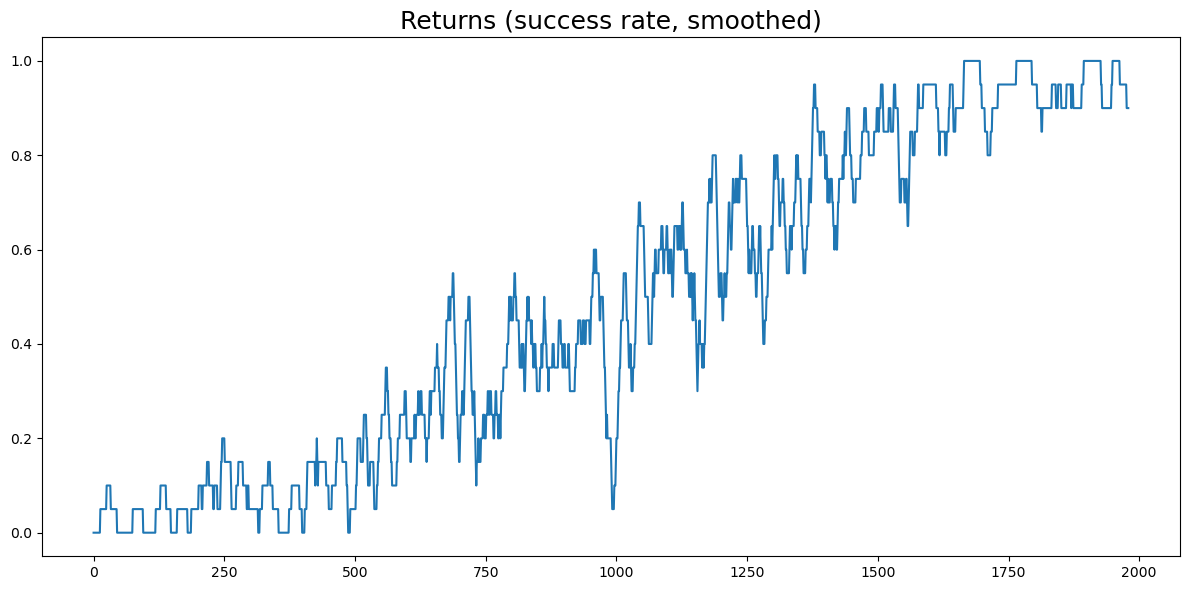

In [6]:
plot_stats({"Returns (success rate, smoothed)": returns})

#### What did the agent learn?

The Q table is the agent's entire knowledge. Three views of it, from coarse to fine: the state values $V(s) = \max_a Q(s,a)$, the greedy policy $\arg\max_a Q(s,a)$, and all four action values per tile.

C:\Anaconda\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


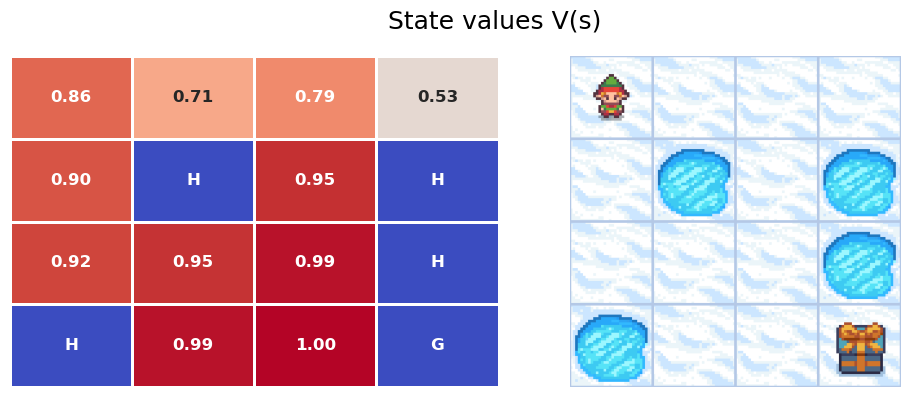

In [7]:
env_render = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
env_render.reset(seed=42)
frame = env_render.render()

plot_values(Q.max(axis=1), frame=frame, env=env_render)

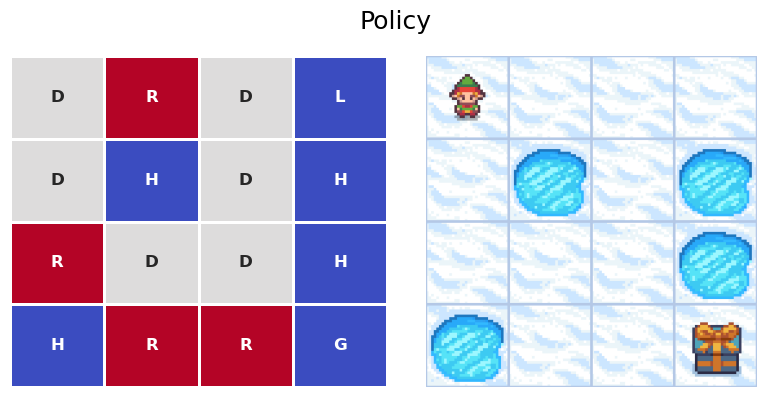

In [8]:
plot_policy(Q, frame=frame, env=env_render)

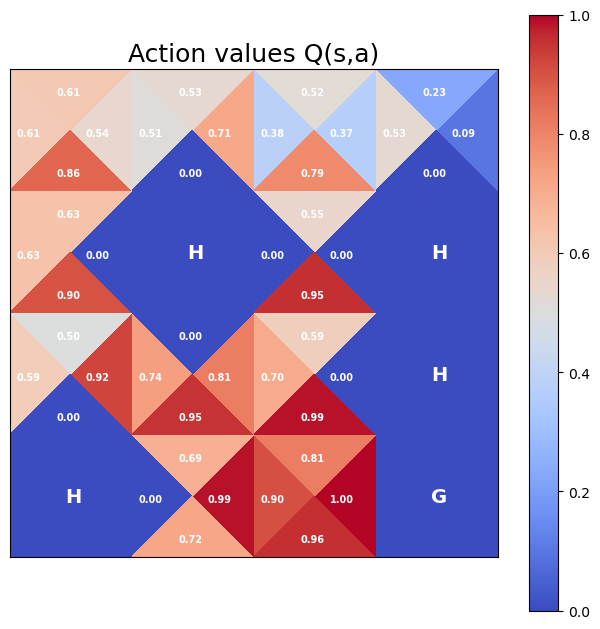

In [9]:
plot_action_values(Q, env=env_render)

Compare with value iteration's result: near the optimal path the values match $\gamma^{\text{steps to gift}}$ well, but tiles the agent rarely visited (corners away from the path) remain rough. Experience-based learning is only as good as the experience: **the table is accurate where the agent has been.** Dynamic programming had no such blind spots because it swept every state equally &mdash; this unevenness is the price of losing the model.

In [10]:
success = evaluate_policy(env, lambda s: int(np.argmax(Q[s])))
print(f"Greedy-policy success rate on firm ice: {success:.1%}")

Greedy-policy success rate on firm ice: 100.0%


In [11]:
test_agent(env_render, lambda s: int(np.argmax(Q[s])), episodes=1)

## The real test: slippery ice

Recall the benchmark: value iteration, *with* the model, reached about 74% on slippery ice &mdash; the optimal success rate. Can SARSA get there from raw experience alone? Stochastic transitions make each TD sample noisier, so we need more episodes for the noise to average out.

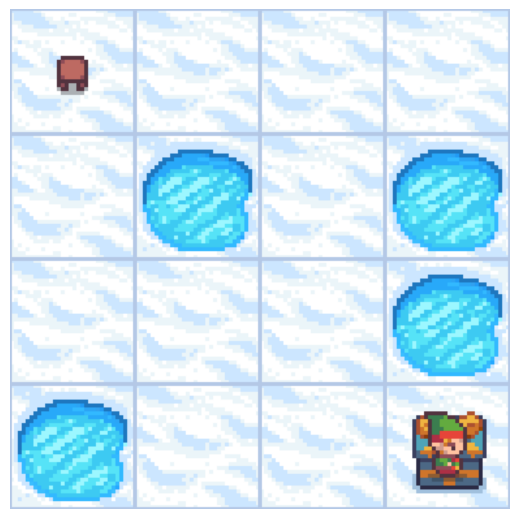

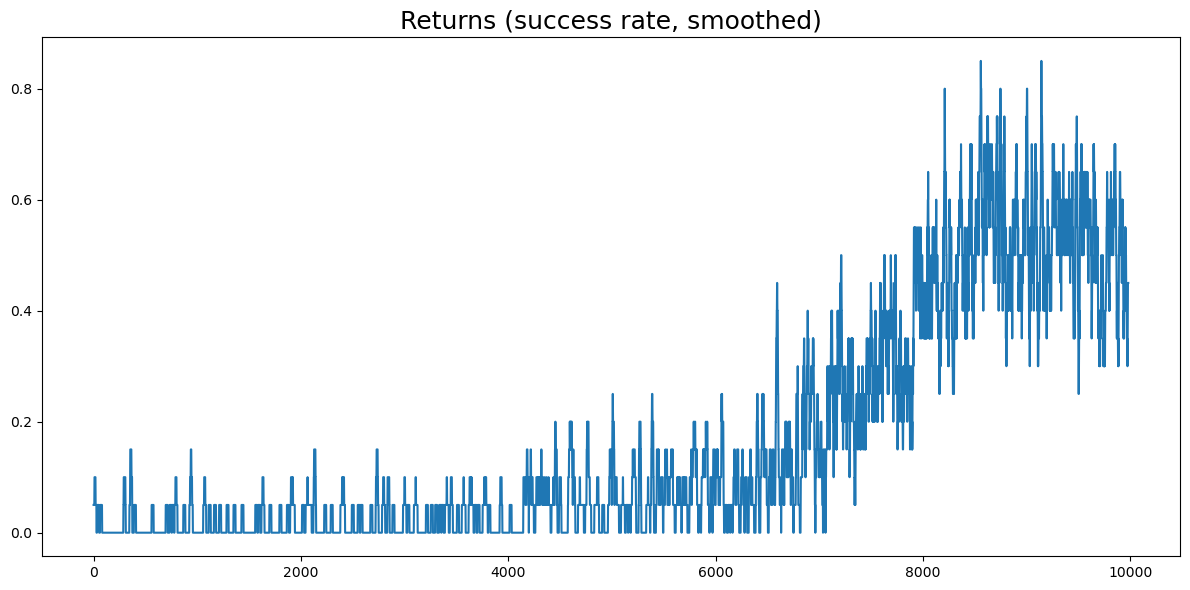

In [12]:
env_slip = gym.make("FrozenLake-v1", is_slippery=True)
seed_everything(env_slip, seed=42)

Q_slip, returns_slip = sarsa(env_slip, episodes=10000)

plot_stats({"Returns (success rate, smoothed)": returns_slip})

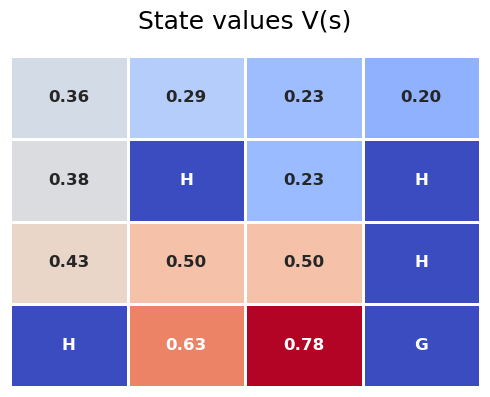

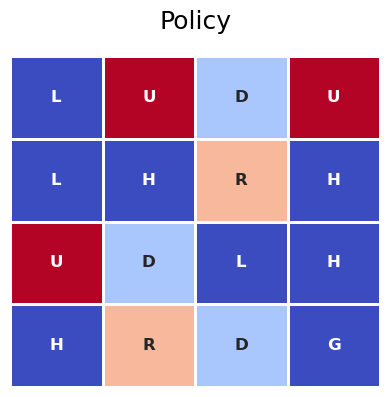

In [13]:
env_slip_render = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")
env_slip_render.reset(seed=42)

plot_values(Q_slip.max(axis=1), env=env_slip_render)
plot_policy(Q_slip, env=env_slip_render)

In [14]:
success_slip = evaluate_policy(env_slip, lambda s: int(np.argmax(Q_slip[s])))
print(f"SARSA greedy policy on slippery ice:  {success_slip:.1%}")
print(f"Value iteration (with the model):     ~74%")
print(f"Random policy:                        ~1.5%")

SARSA greedy policy on slippery ice:  69.9%
Value iteration (with the model):     ~74%
Random policy:                        ~1.5%


SARSA reaches essentially the same success rate as value iteration &mdash; and notice the policy shows the same "wrong-looking" risk-managing arrows, discovered purely from trial and error, without ever seeing a transition probability. That is the remarkable claim of temporal-difference learning, now verified.

In [15]:
test_agent(env_slip_render, lambda s: int(np.argmax(Q_slip[s])), episodes=3)

In [16]:
env.close(); env_render.close(); env_slip.close(); env_slip_render.close()

## Summary

| Ingredient | Role |
|---|---|
| Q table (16 x 4) | the agent's knowledge; replaces $V$ because acting on $V$ needs a model |
| $\varepsilon$-greedy | supplies exploration; decays as the table becomes trustworthy |
| TD target $r + \gamma Q(s',a')$ | one experienced sample of the Bellman expectation |
| TD error $\delta$ | target minus current estimate; the learning signal |
| $\alpha$ | how far to move toward each noisy sample |
| `(not done)` mask | terminal states have no future; forgetting it corrupts the table |
| On-policy | the $a'$ in the target is the action actually taken next |

One question remains. SARSA learns the value of the $\varepsilon$-greedy policy it follows &mdash; exploration mistakes and all. Could the agent instead follow an exploring policy while learning the value of the *greedy* policy directly? It can. That single change of the target produces **Q-Learning**, the subject of the next notebook.

## Resources

[[1] Reinforcement Learning: An Introduction. Ch. 6: Temporal-Difference Learning](https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf)